# 1. Environment Setup
All required libraries are pre-installed on Kaggle (transformers, datasets, evaluate, etc.).
Run the cell below only if something is missing.

In [1]:
import subprocess, sys

# On Kaggle most packages are pre-installed.
# Only install if something is missing (rare).
packages = ["transformers", "datasets", "evaluate", "scikit-learn",
            "seaborn", "matplotlib", "pandas"]
for pkg in packages:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages available.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
All packages available.


# 2. Force Single GPU & Check CUDA
Make sure using single GPU

In [2]:
import os

# Pin to GPU 0 only — avoids slow DataParallel on small strabismus dataset
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


CUDA available: True
Using GPU: Tesla T4
VRAM: 15.6 GB


# 3. Prepare Dataset

**PREFERRED — Upload your pre-split local dataset to Kaggle (685 images, same as local training):**
1. Zip your local `Strabismus/dataset/` folder (the one containing `train/`, `validation/`, `test/`)
2. Go to kaggle.com → Datasets → New Dataset → upload the zip
3. Name the dataset **`strabismus-local`** (slug must match)
4. Add it to this notebook via: Notebook → Add Data → search `strabismus-local`
5. It will be mounted at `/kaggle/input/strabismus-local/`

**FALLBACK (if you haven't uploaded):** The cell below auto-downloads from Kaggle (509 images) and splits it.

In [3]:
import os, shutil, random, kagglehub
from pathlib import Path
from collections import defaultdict

random.seed(42)

processed_dir = Path('/kaggle/working/dataset')

# ── Mode 1: Use pre-uploaded local dataset (685 images, matches local training) ──
UPLOADED_INPUT = Path('/kaggle/input/strabismus-local')

if (processed_dir / 'train').exists():
    print('Dataset already prepared at /kaggle/working/dataset -- skipping.')

elif UPLOADED_INPUT.exists() and any(UPLOADED_INPUT.iterdir()):
    print('Found uploaded dataset at', UPLOADED_INPUT)
    print('Copying pre-split dataset (train / validation / test)...')
    for split in ['train', 'validation', 'test']:
        src_split = UPLOADED_INPUT / split
        dst_split = processed_dir / split
        if src_split.exists():
            shutil.copytree(src_split, dst_split)
        else:
            print(f'  WARNING: {split} folder not found in uploaded dataset!')
    print('Copy complete.')

else:
    # ── Mode 2: Download from kagglehub and split (509 images) ──
    print('Uploaded dataset not found. Downloading from kagglehub (509 images)...')
    path = kagglehub.dataset_download('ananthamoorthya/strabismus')
    raw_data_dir = Path(path)
    print(f'Downloaded to: {path}')

    IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    all_images = [f for f in raw_data_dir.rglob('*') if f.suffix.lower() in IMAGE_EXTS]
    print(f'Total images found: {len(all_images)}')

    if len(all_images) == 0:
        raise RuntimeError(f'No images found in {raw_data_dir}.')

    class_to_images = defaultdict(list)
    for img in all_images:
        class_to_images[img.parent.name].append(img)
    print(f'Classes: {sorted(class_to_images.keys())}')

    splits_ratio = {'train': 0.7, 'validation': 0.15, 'test': 0.15}
    for split in splits_ratio:
        (processed_dir / split).mkdir(parents=True, exist_ok=True)

    for class_name, imgs in class_to_images.items():
        random.shuffle(imgs)
        total     = len(imgs)
        train_end = int(total * splits_ratio['train'])
        val_end   = train_end + int(total * splits_ratio['validation'])
        mapping = {
            'train':      imgs[:train_end],
            'validation': imgs[train_end:val_end],
            'test':       imgs[val_end:],
        }
        for split_name, subset in mapping.items():
            dest = processed_dir / split_name / class_name
            dest.mkdir(parents=True, exist_ok=True)
            for img in subset:
                shutil.copy2(img, dest / img.name)
    print('Split complete.')

# ── Summary ──────────────────────────────────────────────────────────────────
print('\nDataset image counts:')
for split in ['train', 'validation', 'test']:
    count = sum(1 for f in (processed_dir / split).rglob('*') if f.is_file())
    print(f'  {split}: {count} images')
print('\nClasses:')
for cls in sorted((processed_dir / 'train').iterdir()):
    if cls.is_dir():
        n = sum(1 for _ in cls.iterdir())
        print(f'  {cls.name}: {n}')


Uploaded dataset not found. Downloading from kagglehub (509 images)...
Mounting files to /kaggle/input/datasets/ananthamoorthya/strabismus...
Downloaded to: /kaggle/input/datasets/ananthamoorthya/strabismus
Total images found: 509
Classes: ['ESOTROPIA', 'EXOTROPIA', 'HYPERTROPIA', 'HYPOTROPIA', 'NORMAL']
Split complete.

Dataset image counts:
  train: 355 images
  validation: 74 images
  test: 80 images

Classes:
  ESOTROPIA: 70
  EXOTROPIA: 72
  HYPERTROPIA: 71
  HYPOTROPIA: 65
  NORMAL: 77


# 4. Define Training Logic
We define a reusable function to train any given CvT model using Hugging Face `Trainer`. Pre-trained weights will be permanently cached to `./models`.

In [4]:
import numpy as np
import evaluate
import torch
import os
from pathlib import Path
from datasets import load_dataset
from PIL import Image, ImageOps
from torchvision import transforms
from transformers import (
    AutoImageProcessor,
    CvtForImageClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

# Global constants
DATA_DIR = "/kaggle/working/dataset"
MODEL_CACHE_DIR = "/kaggle/working/models"
SEED = 42
set_seed(SEED)

# Ensure cache directory exists
os.makedirs(MODEL_CACHE_DIR, exist_ok=True)

def build_label_mappings():
    train_path = Path(DATA_DIR) / "train"
    class_names = sorted(d.name for d in train_path.iterdir() if d.is_dir())
    id2label = {idx: name for idx, name in enumerate(class_names)}
    label2id = {name: idx for idx, name in id2label.items()}
    return id2label, label2id

id2label, label2id = build_label_mappings()
num_labels = len(id2label)
print(f"Classes: {id2label}")

def load_splits():
    return load_dataset("imagefolder", data_dir=DATA_DIR)

dataset = load_splits()


class PadToSquare:
    """Pad image to a square by adding black bars to the shorter edge.
    This preserves the original aspect ratio — critical for strabismus
    where the spatial geometry of eye alignment carries diagnostic meaning.
    """
    def __call__(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        if w == h:
            return img
        side = max(w, h)
        pad_w = (side - w) // 2
        pad_h = (side - h) // 2
        # Symmetric padding; remainder goes on the right/bottom
        padding = (pad_w, pad_h, side - w - pad_w, side - h - pad_h)
        return ImageOps.expand(img, border=padding, fill=0)


class ImageTransform:
    """Aspect-ratio-preserving image transform for strabismus classification.

    Strategy (replaces RandomResizedCrop which distorts eye geometry):
      Train : PadToSquare -> Resize -> RandomHorizontalFlip -> ColorJitter -> Normalize
      Eval  : PadToSquare -> Resize -> Normalize
    """
    def __init__(self, image_processor, is_train: bool):
        image_size = (
            image_processor.size["shortest_edge"]
            if "shortest_edge" in image_processor.size
            else image_processor.size["height"]
        )
        target = (image_size, image_size)
        mean = image_processor.image_mean
        std  = image_processor.image_std

        if is_train:
            self.transform = transforms.Compose([
                PadToSquare(),
                transforms.Resize(target, interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
                transforms.ToTensor(),
                transforms.Normalize(mean=mean, std=std),
            ])
        else:
            self.transform = transforms.Compose([
                PadToSquare(),
                transforms.Resize(target, interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.ToTensor(),
                transforms.Normalize(mean=mean, std=std),
            ])

    def __call__(self, batch):
        pixel_values = []
        for img in batch["image"]:
            if isinstance(img, Image.Image):
                if img.mode != "RGB":
                    img = img.convert("RGB")
                pixel_values.append(self.transform(img))
            else:
                raise TypeError(f"Expected PIL Image, got {type(img)}")
        batch["pixel_values"] = pixel_values
        return batch


def collate_fn(examples):
    pixel_values = torch.stack([ex["pixel_values"] for ex in examples])
    labels = torch.tensor([ex["label"] for ex in examples], dtype=torch.long)
    return {"pixel_values": pixel_values, "labels": labels}


def build_compute_metrics(num_labels):
    accuracy_metric  = evaluate.load("accuracy")
    f1_metric        = evaluate.load("f1")
    precision_metric = evaluate.load("precision")
    recall_metric    = evaluate.load("recall")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        avg = "macro" if num_labels > 2 else "binary"
        acc  = accuracy_metric.compute(predictions=predictions, references=labels)
        f1   = f1_metric.compute(predictions=predictions, references=labels, average=avg)
        prec = precision_metric.compute(predictions=predictions, references=labels, average=avg, zero_division=0)
        rec  = recall_metric.compute(predictions=predictions, references=labels, average=avg, zero_division=0)
        return {
            "accuracy":  acc["accuracy"],
            f"f1_{avg}": f1["f1"],
            f"precision_{avg}": prec["precision"],
            f"recall_{avg}":    rec["recall"],
        }
    return compute_metrics


def train_and_evaluate(model_name, train_batch_size, eval_batch_size, grad_accum, output_dir_base="/kaggle/working/outputs", num_epochs=200):
    print(f"\n{'='*50}\nStarting training for {model_name}\n{'='*50}")
    output_dir = f"{output_dir_base}/{model_name.replace('/', '_')}"

    # Download/Load cached Image Processor
    image_processor = AutoImageProcessor.from_pretrained(
        model_name,
        cache_dir=MODEL_CACHE_DIR
    )

    # Download/Load cached Model Weights
    model = CvtForImageClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
        cache_dir=MODEL_CACHE_DIR
    )

    train_transform = ImageTransform(image_processor, is_train=True)
    eval_transform  = ImageTransform(image_processor, is_train=False)

    ds_copy = dataset.copy()
    ds_copy["train"].set_transform(train_transform)

    val_dataset = ds_copy["validation"]
    val_dataset.set_transform(eval_transform)

    test_dataset = ds_copy["test"]
    test_dataset.set_transform(eval_transform)

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        save_only_model=True,
        load_best_model_at_end=True,
        metric_for_best_model="val_accuracy",
        greater_is_better=True,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        gradient_accumulation_steps=grad_accum,
        learning_rate=5e-5,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        weight_decay=0.01,
        fp16=torch.cuda.is_available(),
        remove_unused_columns=False,
        dataloader_num_workers=0,
        logging_steps=10,
        report_to=["tensorboard"],
        seed=SEED,
        data_seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=ds_copy["train"],
        eval_dataset={"train": ds_copy["train"], "val": val_dataset},
        data_collator=collate_fn,
        processing_class=image_processor,
        compute_metrics=build_compute_metrics(num_labels),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=35)],
    )

    trainer.train()

    # Evaluate on test set
    print(f"\nEvaluating {model_name} on Test Set...")
    test_metrics = trainer.evaluate(test_dataset, metric_key_prefix="test")

    # Save history before deleting trainer
    log_history = trainer.state.log_history

    # Clean up to avoid OOM
    import gc
    del model
    del trainer
    torch.cuda.empty_cache()
    gc.collect()

    # Return metrics and history for plotting
    return test_metrics, log_history

# Dictionary to hold results
all_results = {}
all_histories = {}


Classes: {0: 'ESOTROPIA', 1: 'EXOTROPIA', 2: 'HYPERTROPIA', 3: 'HYPOTROPIA', 4: 'NORMAL'}


Resolving data files:   0%|          | 0/355 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/74 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

# 5. Training Models

## 5.1  CvT-21 (224 px, ImageNet-1k)

In [5]:
try:
    metrics_CvT_21_1k, history_CvT_21_1k = train_and_evaluate(
        "microsoft/cvt-21",
        train_batch_size=16,
        eval_batch_size=32,
        grad_accum=4,
        num_epochs=200
    )
    all_results["microsoft/cvt-21"] = metrics_CvT_21_1k
    all_histories["microsoft/cvt-21"] = history_CvT_21_1k
except Exception as e:
    print("Error training microsoft/cvt-21: " + str(e))



Starting training for microsoft/cvt-21


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/127M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating microsoft/cvt-21 on Test Set...


early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


## 5.2  CvT-13 (224 px, ImageNet-1k)

In [6]:
try:
    metrics_CvT_13_1k, history_CvT_13_1k = train_and_evaluate(
        "microsoft/cvt-13",
        train_batch_size=32,
        eval_batch_size=64,
        grad_accum=2,
        num_epochs=200
    )
    all_results["microsoft/cvt-13"] = metrics_CvT_13_1k
    all_histories["microsoft/cvt-13"] = history_CvT_13_1k
except Exception as e:
    print("Error training microsoft/cvt-13: " + str(e))



Starting training for microsoft/cvt-13


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/80.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating microsoft/cvt-13 on Test Set...


early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


## 5.3  CvT-21-384 (384 px, ImageNet-1k)

In [7]:
try:
    metrics_CvT_21_384, history_CvT_21_384 = train_and_evaluate(
        "microsoft/cvt-21-384",
        train_batch_size=4,
        eval_batch_size=8,
        grad_accum=4,
        num_epochs=200
    )
    all_results["microsoft/cvt-21-384"] = metrics_CvT_21_384
    all_histories["microsoft/cvt-21-384"] = history_CvT_21_384
except Exception as e:
    print("Error training microsoft/cvt-21-384: " + str(e))



Starting training for microsoft/cvt-21-384


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/127M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/731 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating microsoft/cvt-21-384 on Test Set...


early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


## 5.4  CvT-13-384 (384 px, ImageNet-1k)

In [8]:
try:
    metrics_CvT_13_384, history_CvT_13_384 = train_and_evaluate(
        "microsoft/cvt-13-384",
        train_batch_size=8,
        eval_batch_size=16,
        grad_accum=2,
        num_epochs=200
    )
    all_results["microsoft/cvt-13-384"] = metrics_CvT_13_384
    all_histories["microsoft/cvt-13-384"] = history_CvT_13_384
except Exception as e:
    print("Error training microsoft/cvt-13-384: " + str(e))



Starting training for microsoft/cvt-13-384


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/80.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating microsoft/cvt-13-384 on Test Set...


early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


## 5.5  CvT-21-384-22k (384 px, ImageNet-22k)

In [9]:
try:
    metrics_CvT_21_22k, history_CvT_21_22k = train_and_evaluate(
        "microsoft/cvt-21-384-22k",
        train_batch_size=4,
        eval_batch_size=8,
        grad_accum=4,
        num_epochs=200
    )
    all_results["microsoft/cvt-21-384-22k"] = metrics_CvT_21_22k
    all_histories["microsoft/cvt-21-384-22k"] = history_CvT_21_22k
except Exception as e:
    print("Error training microsoft/cvt-21-384-22k: " + str(e))



Starting training for microsoft/cvt-21-384-22k


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/127M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/731 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating microsoft/cvt-21-384-22k on Test Set...


early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


## 5.6  CvT-13-384-22k (384 px, ImageNet-22k)

In [10]:
try:
    metrics_CvT_13_22k, history_CvT_13_22k = train_and_evaluate(
        "microsoft/cvt-13-384-22k",
        train_batch_size=8,
        eval_batch_size=16,
        grad_accum=2,
        num_epochs=200
    )
    all_results["microsoft/cvt-13-384-22k"] = metrics_CvT_13_22k
    all_histories["microsoft/cvt-13-384-22k"] = history_CvT_13_22k
except Exception as e:
    print("Error training microsoft/cvt-13-384-22k: " + str(e))



Starting training for microsoft/cvt-13-384-22k


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/80.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating microsoft/cvt-13-384-22k on Test Set...


early stopping required metric_for_best_model, but did not find eval_val_accuracy so early stopping is disabled


# 6. Learning Curves

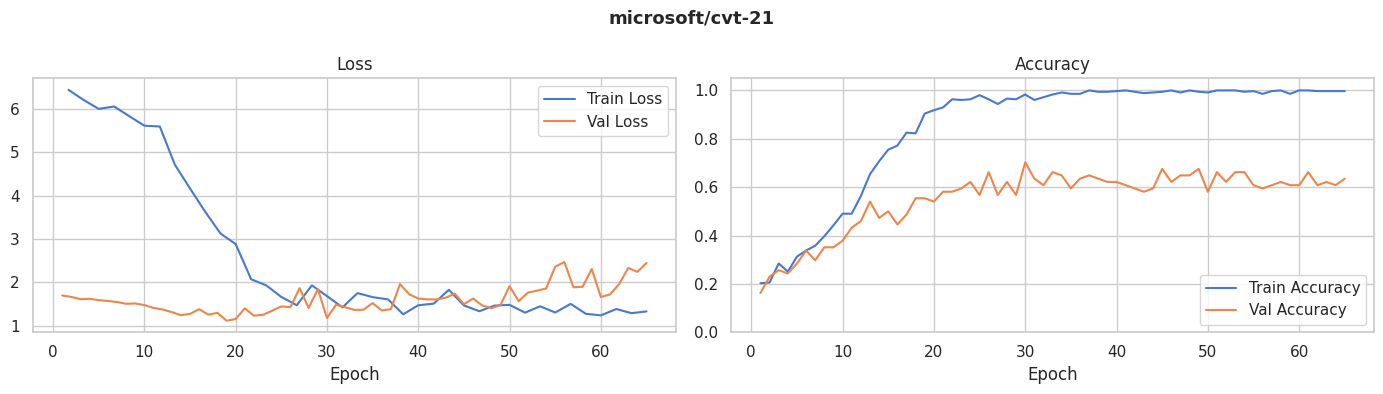

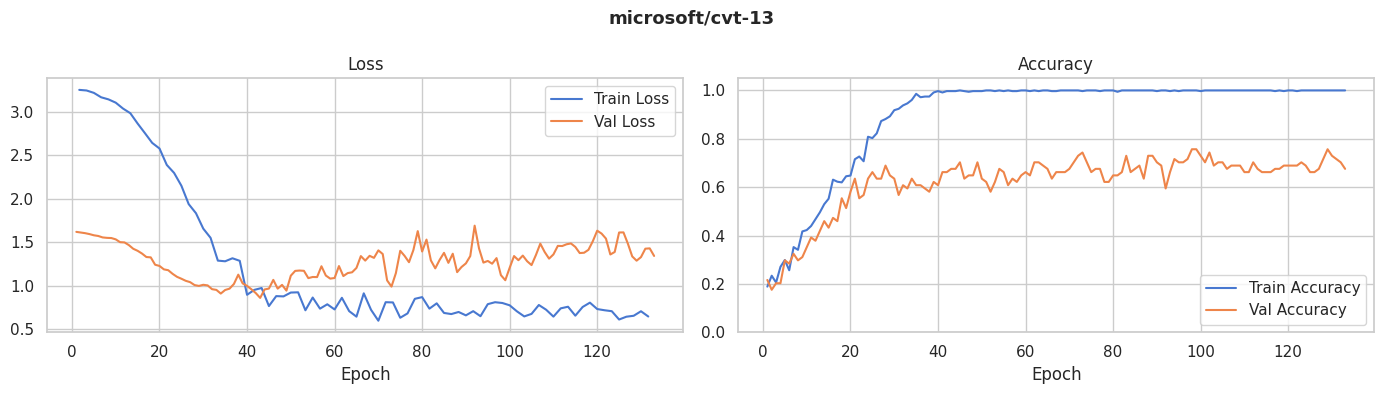

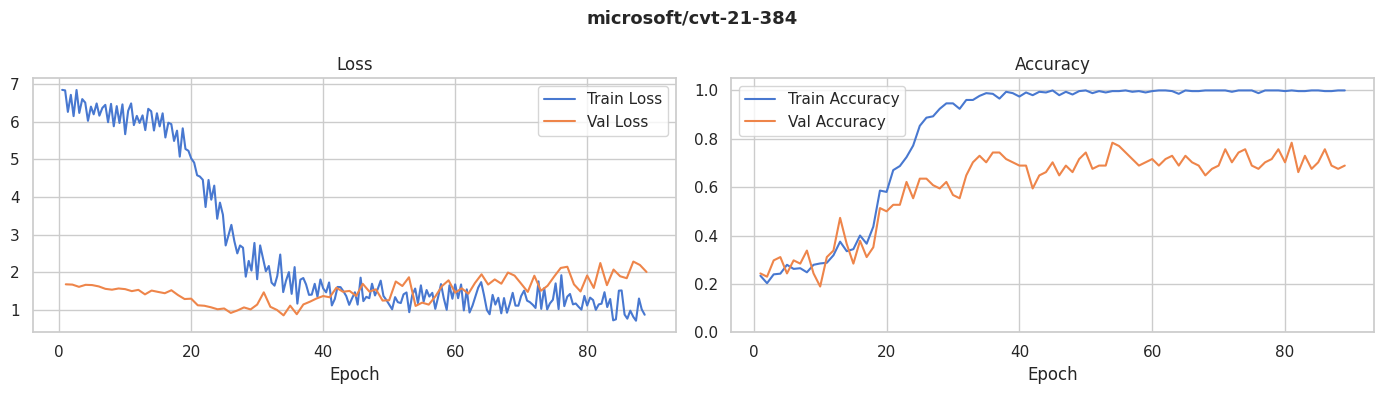

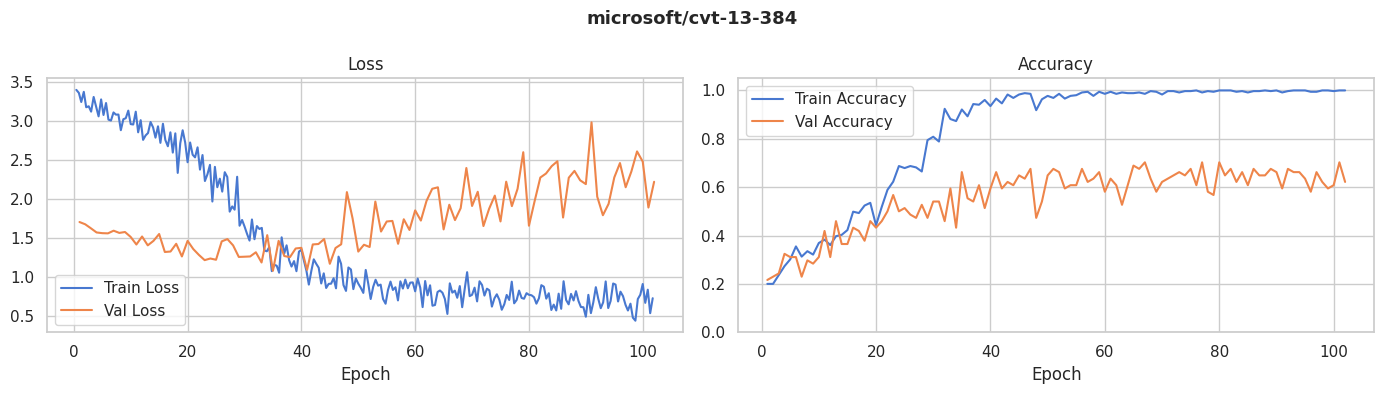

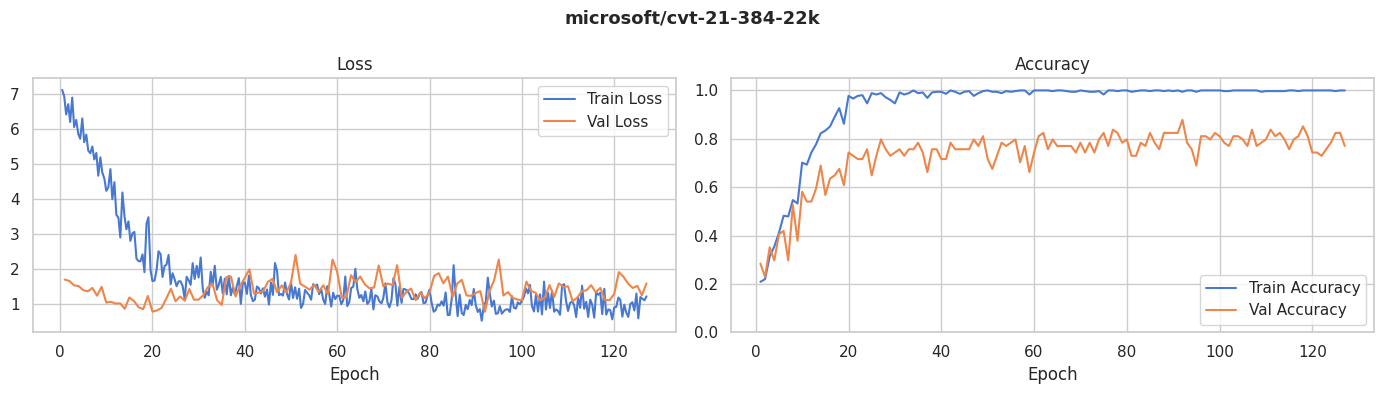

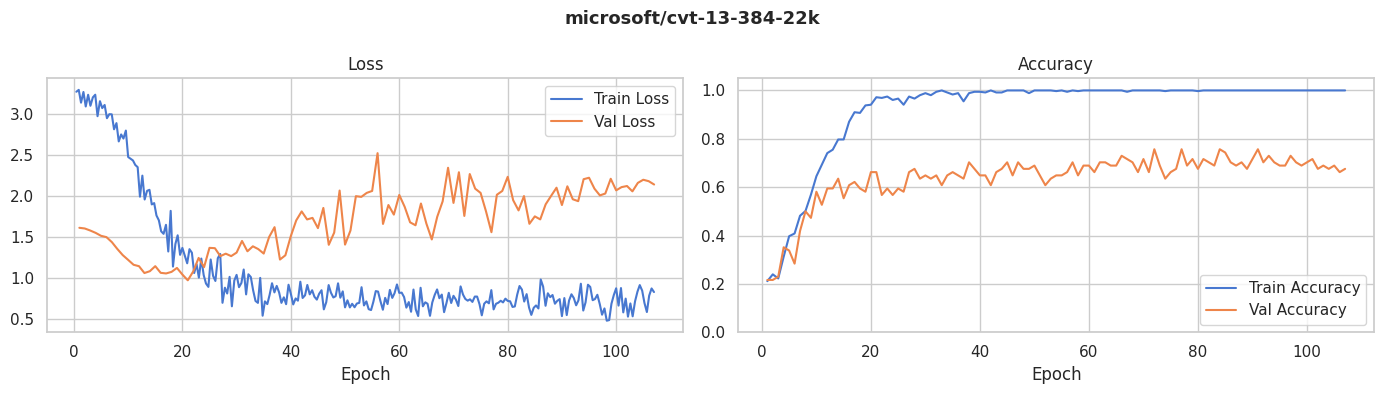

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

for model_name, log_history in all_histories.items():
    train_loss = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e]
    val_loss   = [(e["epoch"], e.get("eval_val_loss", e.get("eval_loss"))) for e in log_history if "eval_val_loss" in e or "eval_loss" in e]
    train_acc  = [(e["epoch"], e["eval_train_accuracy"]) for e in log_history if "eval_train_accuracy" in e]
    val_acc    = [(e["epoch"], e.get("eval_val_accuracy", e.get("eval_accuracy"))) for e in log_history if "eval_val_accuracy" in e or "eval_accuracy" in e]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(model_name, fontsize=13, fontweight="bold")

    if train_loss:
        axes[0].plot([x[0] for x in train_loss], [x[1] for x in train_loss], label="Train Loss")
    if val_loss:
        axes[0].plot([x[0] for x in val_loss], [x[1] for x in val_loss], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    if train_acc:
        axes[1].plot([x[0] for x in train_acc], [x[1] for x in train_acc], label="Train Accuracy")
    if val_acc:
        axes[1].plot([x[0] for x in val_acc], [x[1] for x in val_acc], label="Val Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# 7. Results Table

In [12]:
import pandas as pd

def get_metric(metrics, key):
    for k in metrics:
        if k.endswith(key):
            return metrics[k]
    return None

records = []
for model_name, metrics in all_results.items():
    records.append({
        "Model":     model_name,
        "Accuracy":  round(get_metric(metrics, "accuracy") or 0, 6),
        "F1 (Macro)":round(get_metric(metrics, "f1_macro") or 0, 6),
        "Precision": round(get_metric(metrics, "precision_macro") or 0, 6),
        "Recall":    round(get_metric(metrics, "recall_macro") or 0, 6),
    })

df_all = pd.DataFrame(records)
print(df_all.to_string(index=False))


                   Model  Accuracy  F1 (Macro)  Precision   Recall
        microsoft/cvt-21    0.6625    0.660024   0.659804 0.660686
        microsoft/cvt-13    0.7125    0.712356   0.723537 0.716422
    microsoft/cvt-21-384    0.8250    0.825921   0.840378 0.823676
    microsoft/cvt-13-384    0.6375    0.643470   0.668112 0.634118
microsoft/cvt-21-384-22k    0.8750    0.871195   0.897967 0.872941
microsoft/cvt-13-384-22k    0.7375    0.735412   0.742662 0.735980


# 8. Detailed Comparisons
## 8.1  1k vs 1k — CvT-21 vs CvT-13 (224 px)

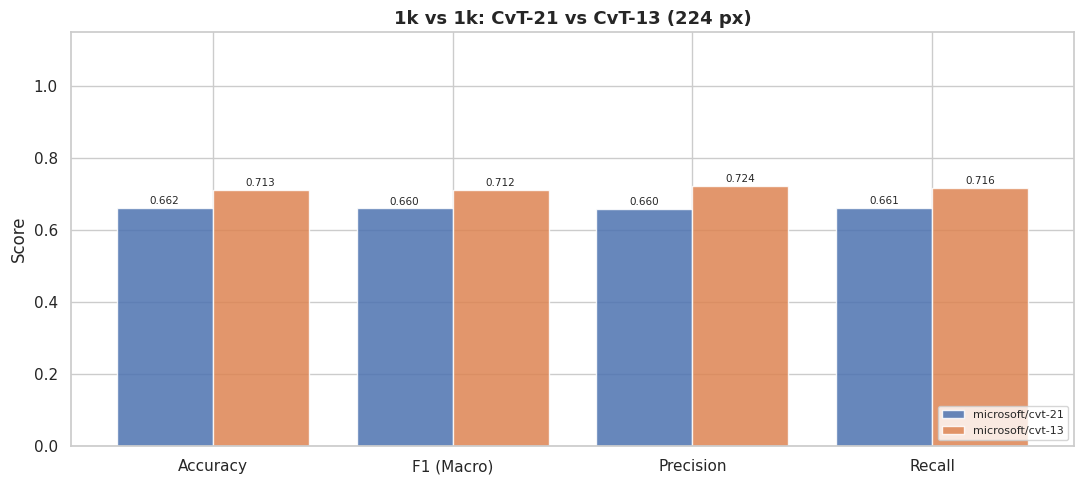

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")
METRICS = ["Accuracy", "F1 (Macro)", "Precision", "Recall"]
COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467bd", "#8c564b"]

def compare_models(df, model_keys, title):
    subset = df[df["Model"].isin(model_keys)].copy()
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        print("No results yet for: " + str(model_keys))
        return
    subset = df[df["Model"].isin(available)]
    x = np.arange(len(METRICS))
    width = 0.8 / len(subset)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (_, row) in enumerate(subset.iterrows()):
        vals = [row[m] for m in METRICS]
        offset = (i - len(subset)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=row["Model"], color=COLORS[i % len(COLORS)], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(METRICS)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

def best_of(df, model_keys):
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        return None
    subset = df[df["Model"].isin(available)]
    return subset.loc[subset["Accuracy"].idxmax(), "Model"]

compare_models(df_all, ['microsoft/cvt-21', 'microsoft/cvt-13'], '1k vs 1k: CvT-21 vs CvT-13 (224 px)')

## 8.2  384-1k vs 384-1k — CvT-21-384 vs CvT-13-384

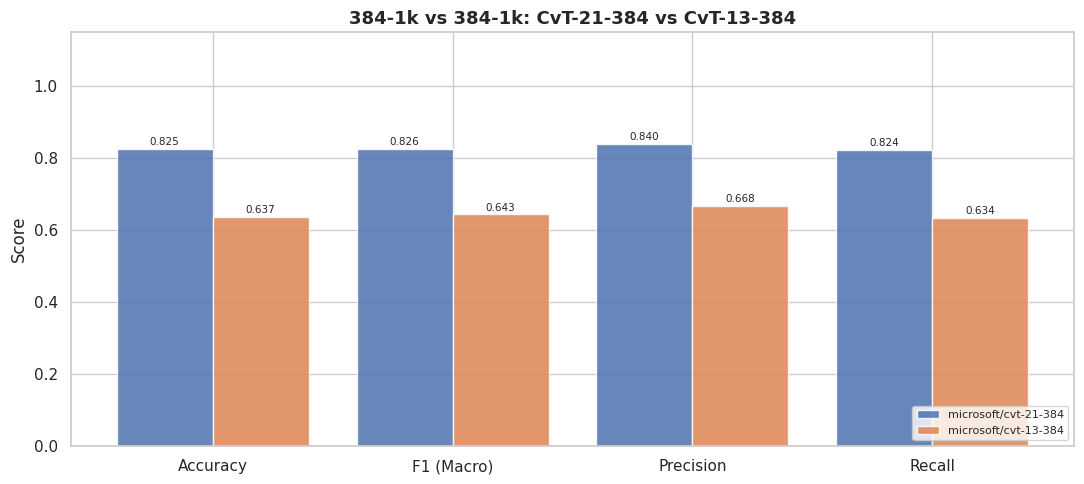

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")
METRICS = ["Accuracy", "F1 (Macro)", "Precision", "Recall"]
COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467bd", "#8c564b"]

def compare_models(df, model_keys, title):
    subset = df[df["Model"].isin(model_keys)].copy()
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        print("No results yet for: " + str(model_keys))
        return
    subset = df[df["Model"].isin(available)]
    x = np.arange(len(METRICS))
    width = 0.8 / len(subset)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (_, row) in enumerate(subset.iterrows()):
        vals = [row[m] for m in METRICS]
        offset = (i - len(subset)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=row["Model"], color=COLORS[i % len(COLORS)], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(METRICS)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

def best_of(df, model_keys):
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        return None
    subset = df[df["Model"].isin(available)]
    return subset.loc[subset["Accuracy"].idxmax(), "Model"]

compare_models(df_all, ['microsoft/cvt-21-384', 'microsoft/cvt-13-384'], '384-1k vs 384-1k: CvT-21-384 vs CvT-13-384')

## 8.3  22k vs 22k — CvT-21-384-22k vs CvT-13-384-22k

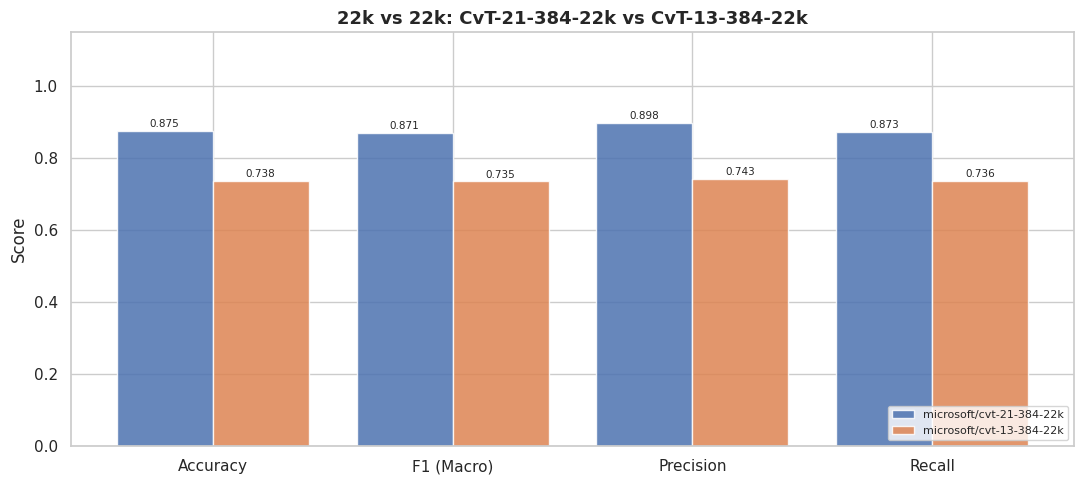

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")
METRICS = ["Accuracy", "F1 (Macro)", "Precision", "Recall"]
COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467bd", "#8c564b"]

def compare_models(df, model_keys, title):
    subset = df[df["Model"].isin(model_keys)].copy()
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        print("No results yet for: " + str(model_keys))
        return
    subset = df[df["Model"].isin(available)]
    x = np.arange(len(METRICS))
    width = 0.8 / len(subset)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (_, row) in enumerate(subset.iterrows()):
        vals = [row[m] for m in METRICS]
        offset = (i - len(subset)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=row["Model"], color=COLORS[i % len(COLORS)], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(METRICS)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

def best_of(df, model_keys):
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        return None
    subset = df[df["Model"].isin(available)]
    return subset.loc[subset["Accuracy"].idxmax(), "Model"]

compare_models(df_all, ['microsoft/cvt-21-384-22k', 'microsoft/cvt-13-384-22k'], '22k vs 22k: CvT-21-384-22k vs CvT-13-384-22k')

## 8.4  Best 1k vs Best 384-1k

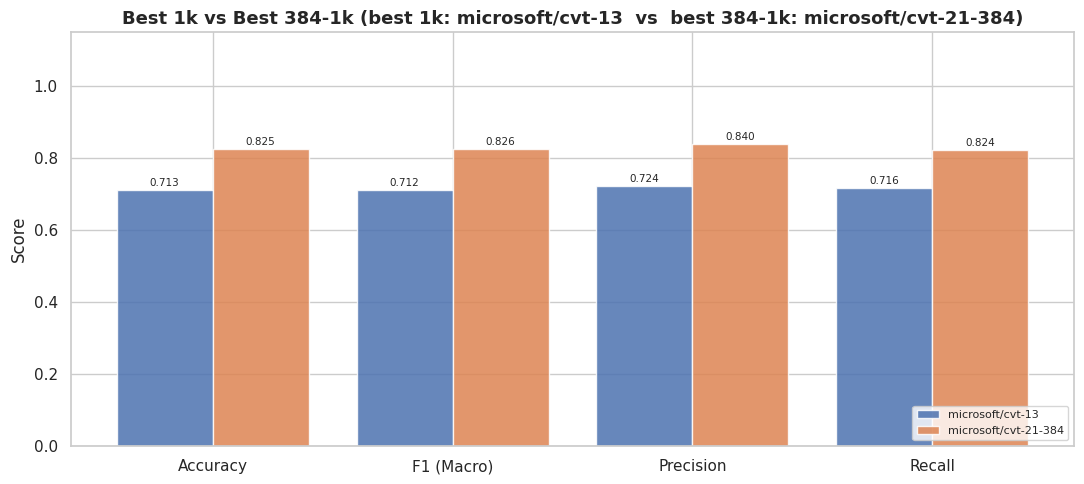

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")
METRICS = ["Accuracy", "F1 (Macro)", "Precision", "Recall"]
COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467bd", "#8c564b"]

def compare_models(df, model_keys, title):
    subset = df[df["Model"].isin(model_keys)].copy()
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        print("No results yet for: " + str(model_keys))
        return
    subset = df[df["Model"].isin(available)]
    x = np.arange(len(METRICS))
    width = 0.8 / len(subset)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (_, row) in enumerate(subset.iterrows()):
        vals = [row[m] for m in METRICS]
        offset = (i - len(subset)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=row["Model"], color=COLORS[i % len(COLORS)], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(METRICS)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

def best_of(df, model_keys):
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        return None
    subset = df[df["Model"].isin(available)]
    return subset.loc[subset["Accuracy"].idxmax(), "Model"]

best_a = best_of(df_all, ['microsoft/cvt-21', 'microsoft/cvt-13'])
best_b = best_of(df_all, ['microsoft/cvt-21-384', 'microsoft/cvt-13-384'])
if best_a and best_b:
    compare_models(df_all, [best_a, best_b],
        "Best 1k vs Best 384-1k (best 1k: " + best_a + "  vs  best 384-1k: " + best_b + ")")
else:
    print("One or both groups have no results yet.")


## 8.5  Best 384-1k vs Best 384-22k

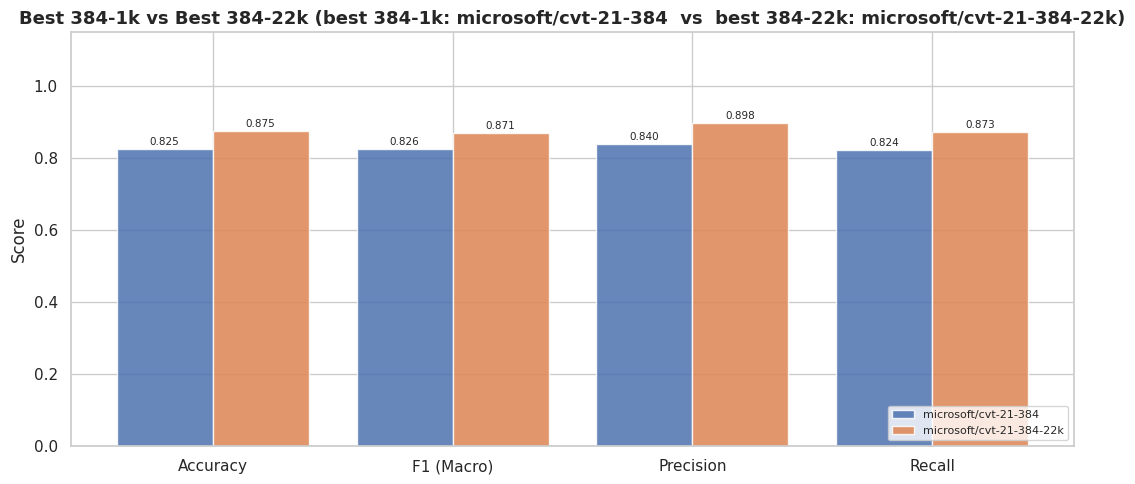

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")
METRICS = ["Accuracy", "F1 (Macro)", "Precision", "Recall"]
COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467bd", "#8c564b"]

def compare_models(df, model_keys, title):
    subset = df[df["Model"].isin(model_keys)].copy()
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        print("No results yet for: " + str(model_keys))
        return
    subset = df[df["Model"].isin(available)]
    x = np.arange(len(METRICS))
    width = 0.8 / len(subset)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (_, row) in enumerate(subset.iterrows()):
        vals = [row[m] for m in METRICS]
        offset = (i - len(subset)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=row["Model"], color=COLORS[i % len(COLORS)], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(METRICS)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

def best_of(df, model_keys):
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        return None
    subset = df[df["Model"].isin(available)]
    return subset.loc[subset["Accuracy"].idxmax(), "Model"]

best_a = best_of(df_all, ['microsoft/cvt-21-384', 'microsoft/cvt-13-384'])
best_b = best_of(df_all, ['microsoft/cvt-21-384-22k', 'microsoft/cvt-13-384-22k'])
if best_a and best_b:
    compare_models(df_all, [best_a, best_b],
        "Best 384-1k vs Best 384-22k (best 384-1k: " + best_a + "  vs  best 384-22k: " + best_b + ")")
else:
    print("One or both groups have no results yet.")


## 8.6  Best 1k vs Best 384-22k

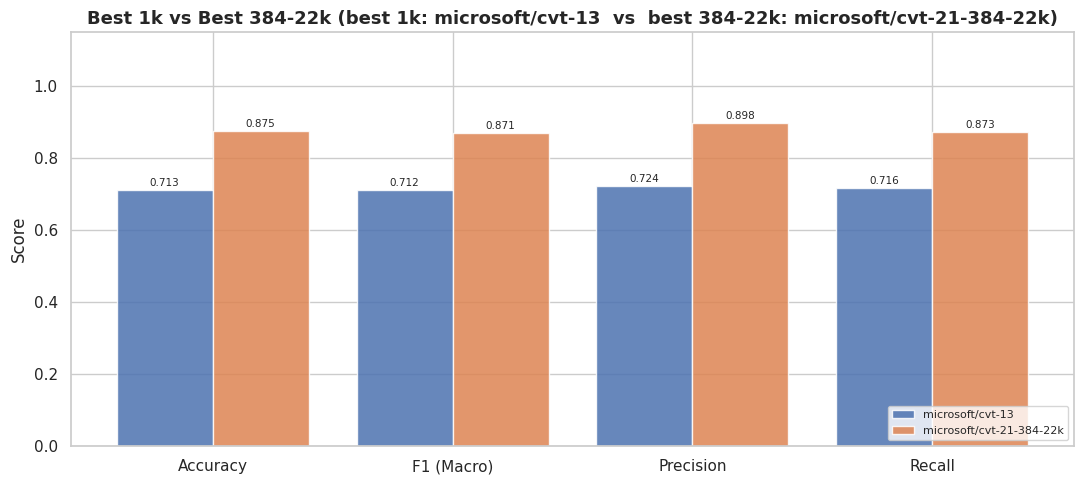

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")
METRICS = ["Accuracy", "F1 (Macro)", "Precision", "Recall"]
COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467bd", "#8c564b"]

def compare_models(df, model_keys, title):
    subset = df[df["Model"].isin(model_keys)].copy()
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        print("No results yet for: " + str(model_keys))
        return
    subset = df[df["Model"].isin(available)]
    x = np.arange(len(METRICS))
    width = 0.8 / len(subset)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (_, row) in enumerate(subset.iterrows()):
        vals = [row[m] for m in METRICS]
        offset = (i - len(subset)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=row["Model"], color=COLORS[i % len(COLORS)], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(METRICS)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

def best_of(df, model_keys):
    available = [m for m in model_keys if m in df["Model"].values]
    if not available:
        return None
    subset = df[df["Model"].isin(available)]
    return subset.loc[subset["Accuracy"].idxmax(), "Model"]

best_a = best_of(df_all, ['microsoft/cvt-21', 'microsoft/cvt-13'])
best_b = best_of(df_all, ['microsoft/cvt-21-384-22k', 'microsoft/cvt-13-384-22k'])
if best_a and best_b:
    compare_models(df_all, [best_a, best_b],
        "Best 1k vs Best 384-22k (best 1k: " + best_a + "  vs  best 384-22k: " + best_b + ")")
else:
    print("One or both groups have no results yet.")



🌟 BEST MODEL: CvT-21 (384px, 22k) 🌟
🌟 TEST ACCURACY: 0.8750 🌟

Loading weights from ./outputs/microsoft_cvt-21-384-22k/checkpoint-2116...


Loading weights:   0%|          | 0/731 [00:00<?, ?it/s]

Running inference on the test set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   ESOTROPIA     0.8750    0.9333    0.9032        15
   EXOTROPIA     1.0000    0.7647    0.8667        17
 HYPERTROPIA     0.8421    1.0000    0.9143        16
  HYPOTROPIA     1.0000    0.6667    0.8000        15
      NORMAL     0.7727    1.0000    0.8718        17

    accuracy                         0.8750        80
   macro avg     0.8980    0.8729    0.8712        80
weighted avg     0.8967    0.8750    0.8716        80



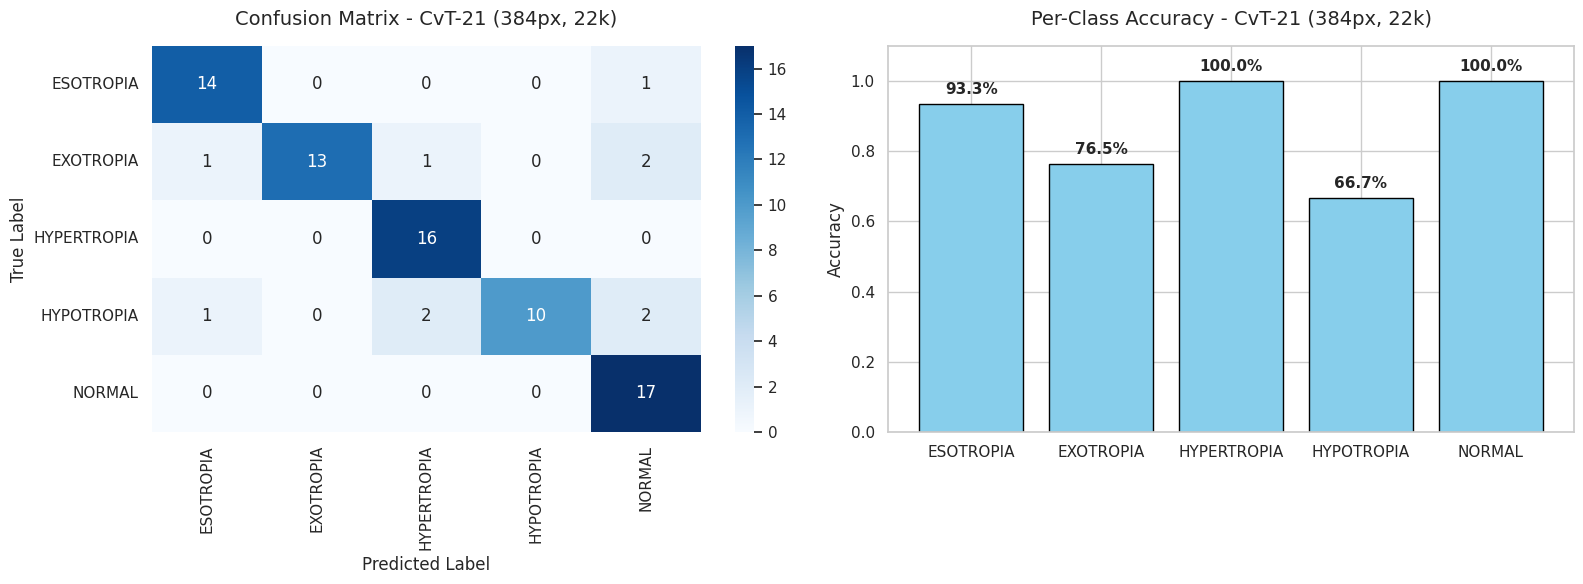

In [19]:
# 9. Best Model Deep Dive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch
import os
from transformers import AutoImageProcessor, CvtForImageClassification

# 1. Identify the best model from the results
results = [
    ("CvT-21 (224px)", globals().get("metrics_CvT_21_1k")),
    ("CvT-13 (224px)", globals().get("metrics_CvT_13_1k")),
    ("CvT-21 (384px)", globals().get("metrics_CvT_21_384")),
    ("CvT-13 (384px)", globals().get("metrics_CvT_13_384")),
    ("CvT-21 (384px, 22k)", globals().get("metrics_CvT_21_22k")),
    ("CvT-13 (384px, 22k)", globals().get("metrics_CvT_13_22k")),
]

best_model_name = ""
best_acc = 0.0
best_model_path_suffix = ""

mapping = {
    "CvT-21 (224px)": "microsoft/cvt-21",
    "CvT-13 (224px)": "microsoft/cvt-13",
    "CvT-21 (384px)": "microsoft/cvt-21-384",
    "CvT-13 (384px)": "microsoft/cvt-13-384",
    "CvT-21 (384px, 22k)": "microsoft/cvt-21-384-22k",
    "CvT-13 (384px, 22k)": "microsoft/cvt-13-384-22k",
}

for name, metric in results:
    if metric is not None and "test_accuracy" in metric:
        acc = metric["test_accuracy"]
        if acc > best_acc:
            best_acc = acc
            best_model_name = name
            best_model_path_suffix = mapping[name].replace("/", "_")

if best_acc == 0.0:
    print("No trained models found or accuracy was 0. Please train models first.")
else:
    print(f"\n{'='*50}")
    print(f"🌟 BEST MODEL: {best_model_name} 🌟")
    print(f"🌟 TEST ACCURACY: {best_acc:.4f} 🌟")
    print(f"{'='*50}\n")
    
    # 2. Locate the best checkpoint
    output_dir = f"./outputs/{best_model_path_suffix}"
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith("checkpoint-")] if os.path.exists(output_dir) else []
    
    if not checkpoints:
        print("No checkpoint found in", output_dir)
    else:
        best_ckpt = os.path.join(output_dir, checkpoints[0])
        print(f"Loading weights from {best_ckpt}...")
        
        # 3. Load model and processor
        processor = AutoImageProcessor.from_pretrained(best_ckpt)
        model = CvtForImageClassification.from_pretrained(best_ckpt)
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)
        model.eval()
        
        # 4. Run predictions on test dataset
        # Re-apply transform using the correct processor for this specific model architecture
        eval_dataset = dataset["test"]
        eval_dataset.set_transform(ImageTransform(processor, is_train=False))
        
        print("Running inference on the test set...")
        y_true = []
        y_pred = []
        
        with torch.no_grad():
            for item in eval_dataset:
                pixel_values = item["pixel_values"].unsqueeze(0).to(device)
                labels = item["label"]
                
                outputs = model(pixel_values)
                logits = outputs.logits
                pred = logits.argmax(-1).item()
                
                y_true.append(labels)
                y_pred.append(pred)
                
        # 5. Generate metrics and plots
        class_names = list(label2id.keys())
        
        # Classification Report
        print("\n" + "="*50)
        print("CLASSIFICATION REPORT")
        print("="*50)
        print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
        
        # Visualizations (Side by Side)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names,
                    yticklabels=class_names, ax=ax1)
        ax1.set_title(f"Confusion Matrix - {best_model_name}", fontsize=14, pad=15)
        ax1.set_ylabel('True Label', fontsize=12)
        ax1.set_xlabel('Predicted Label', fontsize=12)
        
        # Per-class accuracy bar chart
        per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
        bars = ax2.bar(class_names, per_class_acc, color='skyblue', edgecolor='black')
        ax2.set_title(f"Per-Class Accuracy - {best_model_name}", fontsize=14, pad=15)
        ax2.set_ylabel('Accuracy', fontsize=12)
        ax2.set_ylim(0, 1.1)
        
        # Add value labels on bars
        for bar in bars:
            yval = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, 
                     f'{yval:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
            
        plt.tight_layout()
        plt.show()
